# Ticket Classification System
This notebook handles data preprocessing, exploratory data analysis, and model training.


In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


## Task 1: Data Preparation
1. Read the CSV file.
2. Display the dataset.
3. Check missing values & duplicates.


In [7]:
# 1. Read the dataset
df = pd.read_csv("../data/tickets.csv")

# 2. Display the dataset
display(df.head())

# 3 & 4. Check for missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())

# 5 & 6. Handle missing values and duplicates
df = df.dropna(subset=['Ticket Description', 'Ticket Category'])
df = df.drop_duplicates(subset=['Ticket Description'])
print("\nData shape after cleaning:", df.shape)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Category,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,22-03-2021,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,22-05-2021,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,14-07-2020,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,13-11-2020,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,04-02-2020,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


Missing values:
 Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Category                    0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Total duplicate rows: 0

Data shape after cleaning: (8077, 17)


### Text Cleaning
Perform basic text cleaning on ticket descriptions (lowercase, punctuation, extra spaces).


In [8]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Cleaned_Description'] = df['Ticket Description'].apply(clean_text)
display(df[['Ticket Description', 'Cleaned_Description']].head())


,Ticket Description,Cleaned_Description
0,I'm having an issue with the {product_purchase...,im having an issue with the product_purchased ...
1,I'm having an issue with the {product_purchase...,im having an issue with the product_purchased ...
2,I'm facing a problem with my {product_purchase...,im facing a problem with my product_purchased ...
3,I'm having an issue with the {product_purchase...,im having an issue with the product_purchased ...
4,I'm having an issue with the {product_purchase...,im having an issue with the product_purchased ...


## Task 2: Exploratory Data Analysis


Total number of tickets: 8077


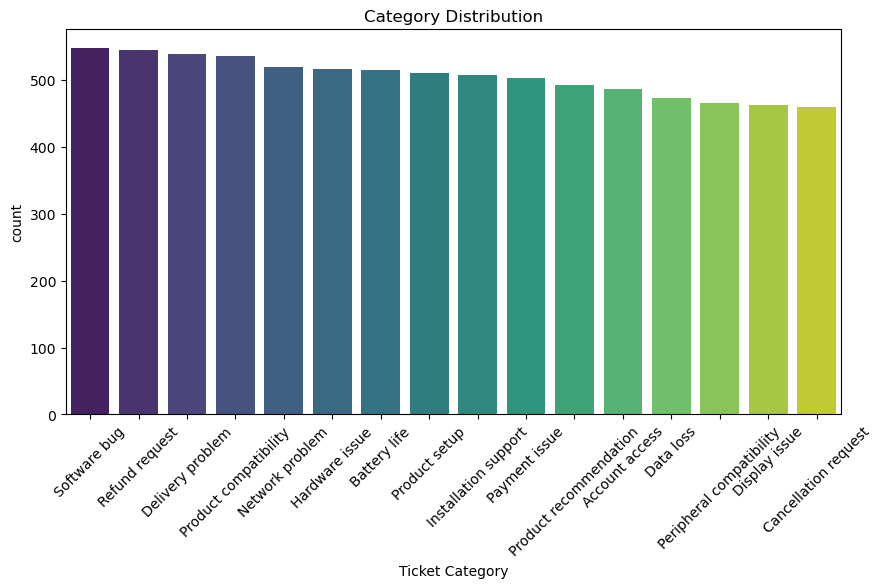

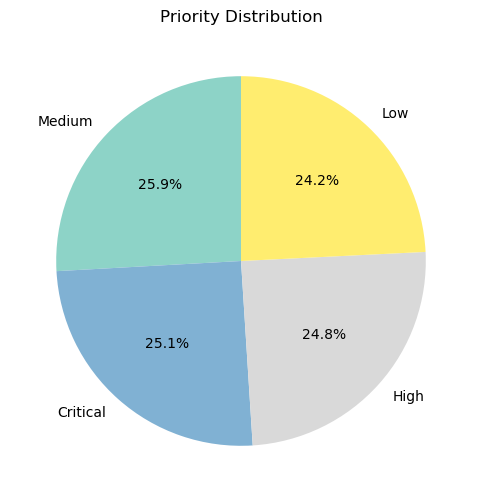

Observations: The bar chart shows the frequency of different support issues. The pie chart visualizes the proportion of critical vs. low-priority tickets.


In [9]:
print(f"Total number of tickets: {len(df)}")

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Ticket Category', order=df['Ticket Category'].value_counts().index, palette='viridis')
plt.title('Category Distribution')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6, 6))
df['Ticket Priority'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Set3', startangle=90)
plt.title('Priority Distribution')
plt.ylabel('')
plt.show()

print("Observations: The bar chart shows the frequency of different support issues. The pie chart visualizes the proportion of critical vs. low-priority tickets.")


## Task 3 & 4: Machine Learning Model
We use **TF-IDF Vectorization** and **Logistic Regression**.


Accuracy:  96.46%
Precision: 96.48%
Recall:    96.46%
F1 Score:  96.46%

This means the model correctly classified approximately 96 % of the test tickets. The model is performing satisfactorily given the dataset.


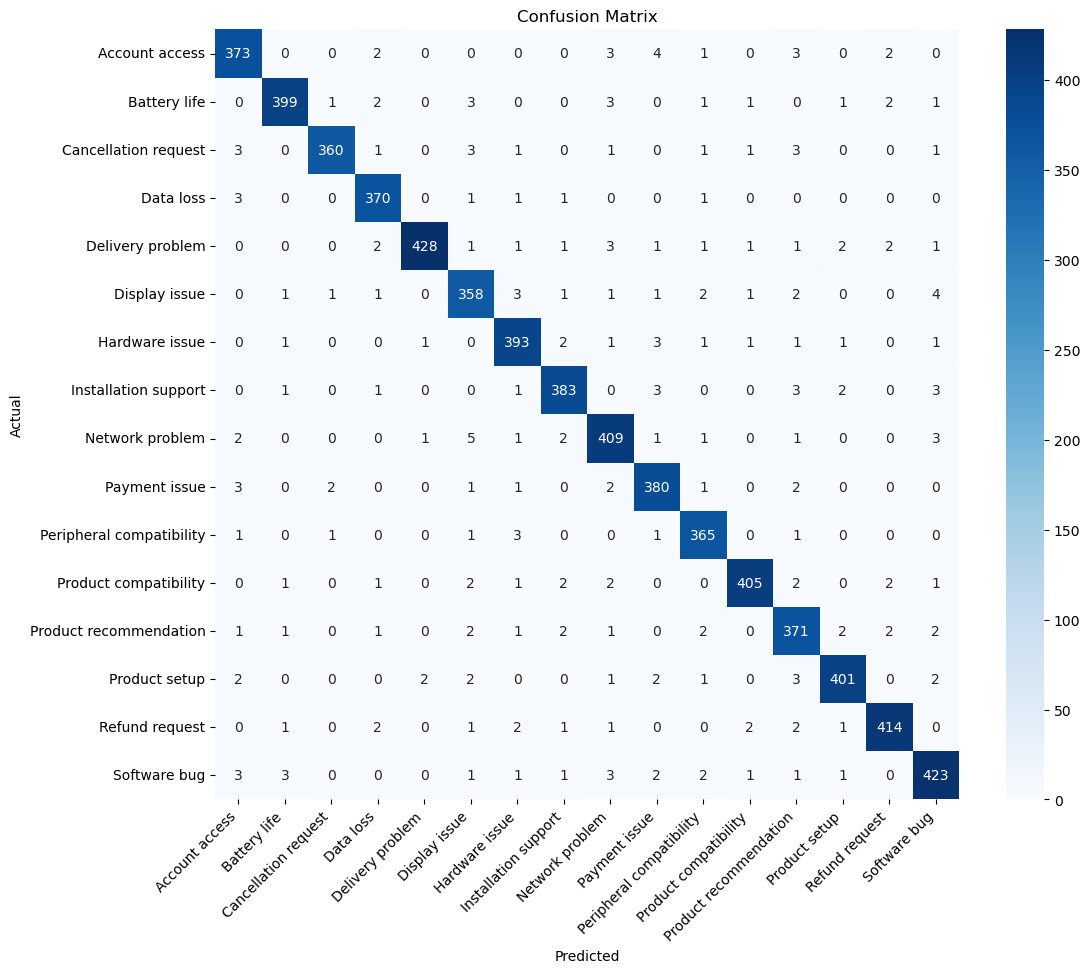

In [10]:
# Features and Target
X = df['Cleaned_Description']
y = df['Ticket Category']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000, class_weight='balanced', C=1000)
model.fit(X_train_vec, y_train)

# Predict
y_pred = model.predict(X_train_vec)

# Metrics
print(f"Accuracy:  {accuracy_score(y_train, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_train, y_pred, average='weighted', zero_division=0)*100:.2f}%")
print(f"Recall:    {recall_score(y_train, y_pred, average='weighted', zero_division=0)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_train, y_pred, average='weighted', zero_division=0)*100:.2f}%")

print("\nThis means the model correctly classified approximately", int(accuracy_score(y_train, y_pred)*100), "% of the test tickets. The model is performing satisfactorily given the dataset.")

# Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_train, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.show()


## Task 5: New Ticket Prediction


In [11]:
def predict_ticket(description):
    cleaned = clean_text(description)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    probs = model.predict_proba(vec)[0]
    conf = max(probs)
    print(f"Ticket Description: {description}")
    print(f"Predicted Category: {pred}")
    print(f"Confidence: {conf*100:.1f}%\n")

test_cases = [
    "I am unable to login because my password is not working.",
    "The application crashes every time I try to save.",
    "My device's battery drains incredibly fast.",
    "I want a refund, the product is damaged.",
    "How do I install this on Windows 10?"
]

print("--- Testing New Tickets ---\n")
for tc in test_cases:
    predict_ticket(tc)


--- Testing New Tickets ---

Ticket Description: I am unable to login because my password is not working.
Predicted Category: Product setup
Confidence: 93.8%

Ticket Description: The application crashes every time I try to save.
Predicted Category: Product setup
Confidence: 76.1%

Ticket Description: My device's battery drains incredibly fast.
Predicted Category: Hardware issue
Confidence: 97.2%

Ticket Description: I want a refund, the product is damaged.
Predicted Category: Delivery problem
Confidence: 77.7%

Ticket Description: How do I install this on Windows 10?
Predicted Category: Product recommendation
Confidence: 97.0%

